# SENG 474 Assignment 1

In [1]:
# If you are using Google Colab, you can mount your Google Drive to access files stored there. Just replace the file path with the actual path to your file in Google Drive. 
# from google.colab import drive
# drive.mount('/content/drive')
# raw_data =  pd.read_csv('/content/drive/MyDrive/Colab Notebooks/data.filetype')

## Imports

To keep things organized please place all imports in the cell below. A few that you will likely use have been included for you.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.model_selection import train_test_split, KFold, cross_validate
from sklearn.preprocessing import MinMaxScaler, add_dummy_feature
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.impute import SimpleImputer
med_imputer = SimpleImputer(strategy="median")
# use standardscaler since z-score (standard) normalization isn't sensitive to (extreme) outliers
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
from sklearn.metrics import mean_squared_error

## Part 1 - Initial Data Exploration

In this section you should take an initial look at the dataset and examine it for missing values and/or outliers and determine what should be done to the data to prepare it for your machine learning models.
You should evaluate whether outliers in the data ought to be removed as well as if it is reasonable to remove entries that have missing data or whether imputation might be a better solution. There is no single correct answer as to how you should handle the data, it is up to you to justify the decisions you have made and why you made them in your report.

**Hints:**

Two columns have had gaussian noise added, one columns has NaN values, and some synthetic extreme outliers have been added to the data set. 

Using interquartile range provides a simple method for trimming outliers.

You may even want to perform K-Means clustering on the raw data first to inform your proccessing.

In [3]:
# Use this commented out line if you're trying to run this with a local file:
# raw_data =  pd.read_csv('A1_data.csv', header=None).to_numpy()
# print(raw_data[:5])

raw_data = pd.read_csv('A1_data.csv')
# raw_data.head()

# Find missing data (NaNs)
raw_data.info()
# used to reveal counts of all non-null data compared to number of columns
# raw_data.describe()

print("percentage NaN alcohol values:")
print(raw_data[["alcohol"]].isnull().sum() / len(raw_data))
# revealed that the alcohol column has 18.87% NaN values. This is under 20%, which is generally considered in the range of acceptable imputation

# performing median imputation on alcohol
raw_data_alcohol_num = raw_data[["alcohol"]]
med_imputer.fit(raw_data_alcohol_num)

print("alcohol median:", raw_data_alcohol_num.median())
print(med_imputer.statistics_)

X = med_imputer.transform(raw_data_alcohol_num)
# apply imputed data to raw_data
raw_data["alcohol"] = X
imputed_data = raw_data

# check for nans
print("imputed data info:")
imputed_data.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6821 entries, 0 to 6820
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6821 non-null   float64
 1   volatile acidity      6821 non-null   float64
 2   citric acid           6821 non-null   float64
 3   residual sugar        6821 non-null   float64
 4   chlorides             6821 non-null   float64
 5   free sulfur dioxide   6821 non-null   float64
 6   total sulfur dioxide  6821 non-null   float64
 7   density               6821 non-null   float64
 8   pH                    6821 non-null   float64
 9   sulphates             6821 non-null   float64
 10  alcohol               5534 non-null   float64
 11  quality               6821 non-null   int64  
 12  class                 6821 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 692.9 KB
percentage NaN alcohol values:
alcohol    0.188682
dtype: float64
alcohol m

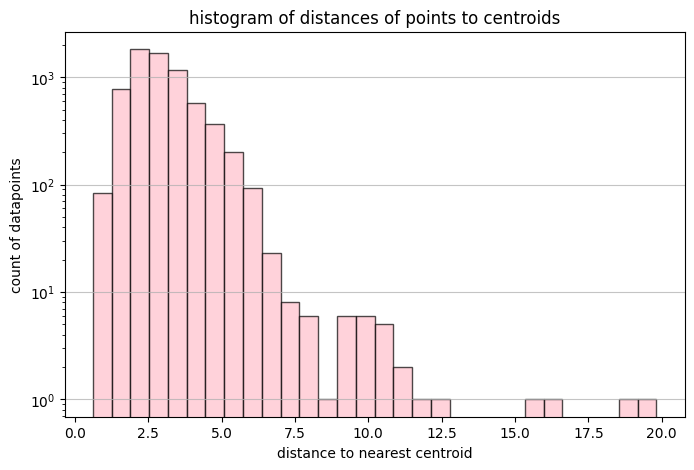

In [4]:
# Visualizing the data (explorative k-means clustering)
# perform k-means clustering
scaled_data = scaler.fit_transform(imputed_data.select_dtypes(include=["number"]))
kmeans = KMeans(n_clusters=2, random_state=42, n_init='auto')
kmeans.fit(scaled_data)

# find distances from each point to nearest centroid to detect outliers
distance = kmeans.transform(scaled_data).min(axis=1)

# plotting distance data to visualize outliers
plt.figure(figsize=(8,5))
plt.hist(distance, bins=30, edgecolor="black", alpha=0.7, color="pink")
plt.xlabel("distance to nearest centroid")
plt.ylabel("count of datapoints")
plt.title("histogram of distances of points to centroids")
plt.grid(axis="y", alpha = 0.75)
# applying a logarithmic yscale since linear scale made outlier columns with small count of datapoints hard to see on plot
plt.yscale("log")
plt.show()


In [5]:

# looks like normal curve until after the 7.5 mark.
# an appropriate cut-off line for outliers would be the 8 mark.

# After initially trying to perform IQR on all columns, and having too many data entries removed for even a very strict IQR multiplier,
# I checked to see if only a couple columns are causing most of the gaussian noise (from the above hint).
for col in imputed_data.select_dtypes(include=["number"]).columns:
    Q1 = imputed_data[col].quantile(0.25)
    Q3 = imputed_data[col].quantile(0.75)
    IQR = Q3 - Q1
    n_outliers = ((imputed_data[col] < Q1 - 3*IQR) | (imputed_data[col] > Q3 + 3*IQR)).sum()
    if n_outliers > 0.1 * len(imputed_data): print(f"{col}: {n_outliers} outliers")

noisy_cols = ["volatile acidity", "class"]

clean_data = imputed_data.copy()
for col in clean_data.select_dtypes(include=["number"]).columns:
    if col in noisy_cols:
        continue
    Q1 = clean_data[col].quantile(0.25)
    Q3 = clean_data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 3 * IQR
    upper = Q3 + 3 * IQR
    clean_data = clean_data[(clean_data[col] >= lower) & (clean_data[col] <= upper)]

print(f"percentage of rows removed: {1 - (len(clean_data) / len(imputed_data))}")

volatile acidity: 1699 outliers
class: 1677 outliers
percentage of rows removed: 0.08605776279137956


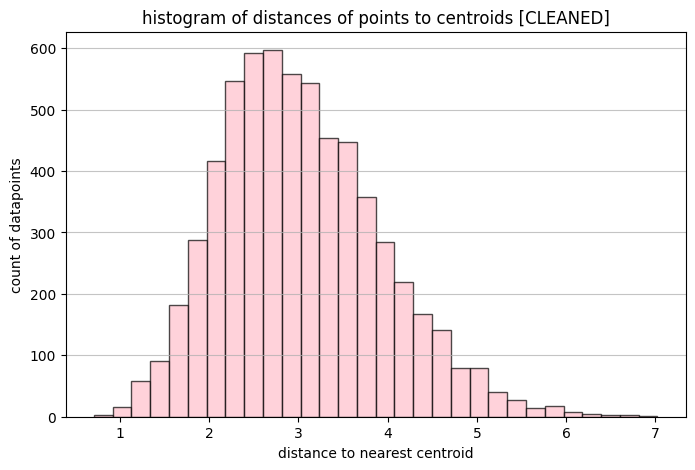

In [6]:
scaled_data = scaler.fit_transform(clean_data.select_dtypes(include=["number"]))
kmeans = KMeans(n_clusters=2, random_state=42, n_init='auto')
kmeans.fit(scaled_data)

# find distances from each point to nearest centroid to detect outliers
distance = kmeans.transform(scaled_data).min(axis=1)

# plotting distance data to visualize outliers
plt.figure(figsize=(8,5))
plt.hist(distance, bins=30, edgecolor="black", alpha=0.7, color="pink")
plt.xlabel("distance to nearest centroid")
plt.ylabel("count of datapoints")
plt.title("histogram of distances of points to centroids [CLEANED]")
plt.grid(axis="y", alpha = 0.75)
plt.show()

# alot more normal

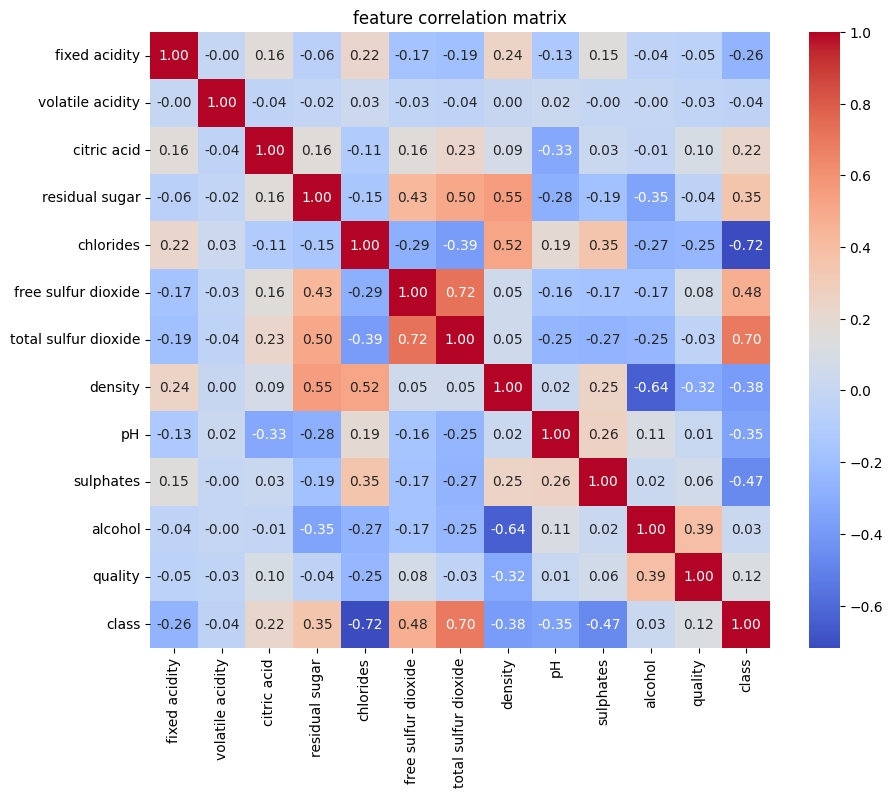

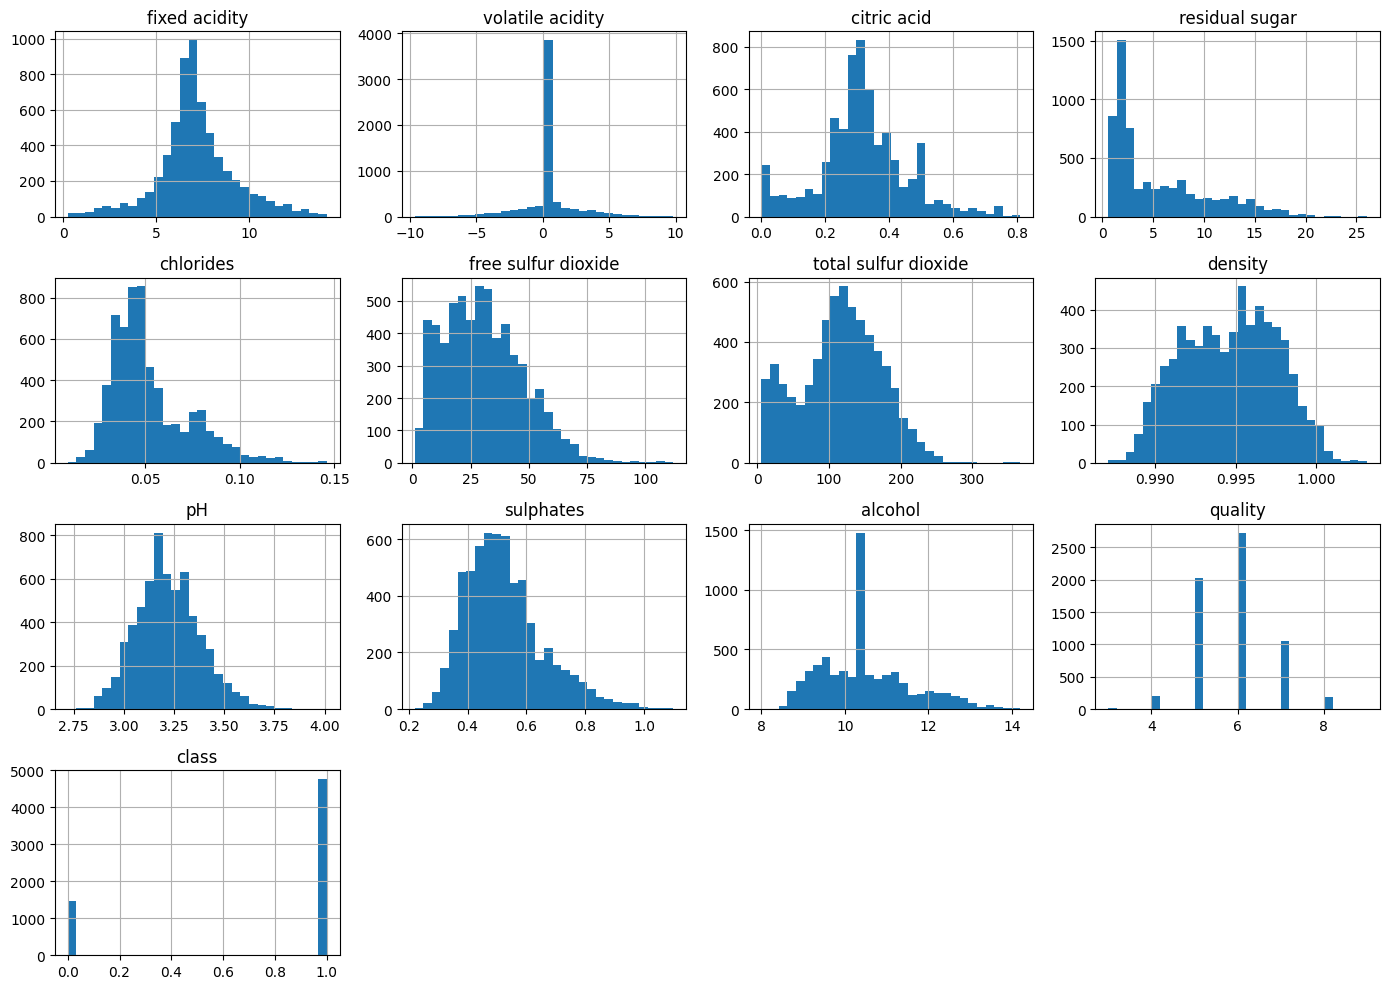

In [7]:

# examining correlations
corr_matrix = clean_data.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("feature correlation matrix")
plt.show()

# analyzing distribution the data is drawn from
clean_data.hist(figsize=(14, 10), bins=30)
plt.tight_layout()
plt.show()

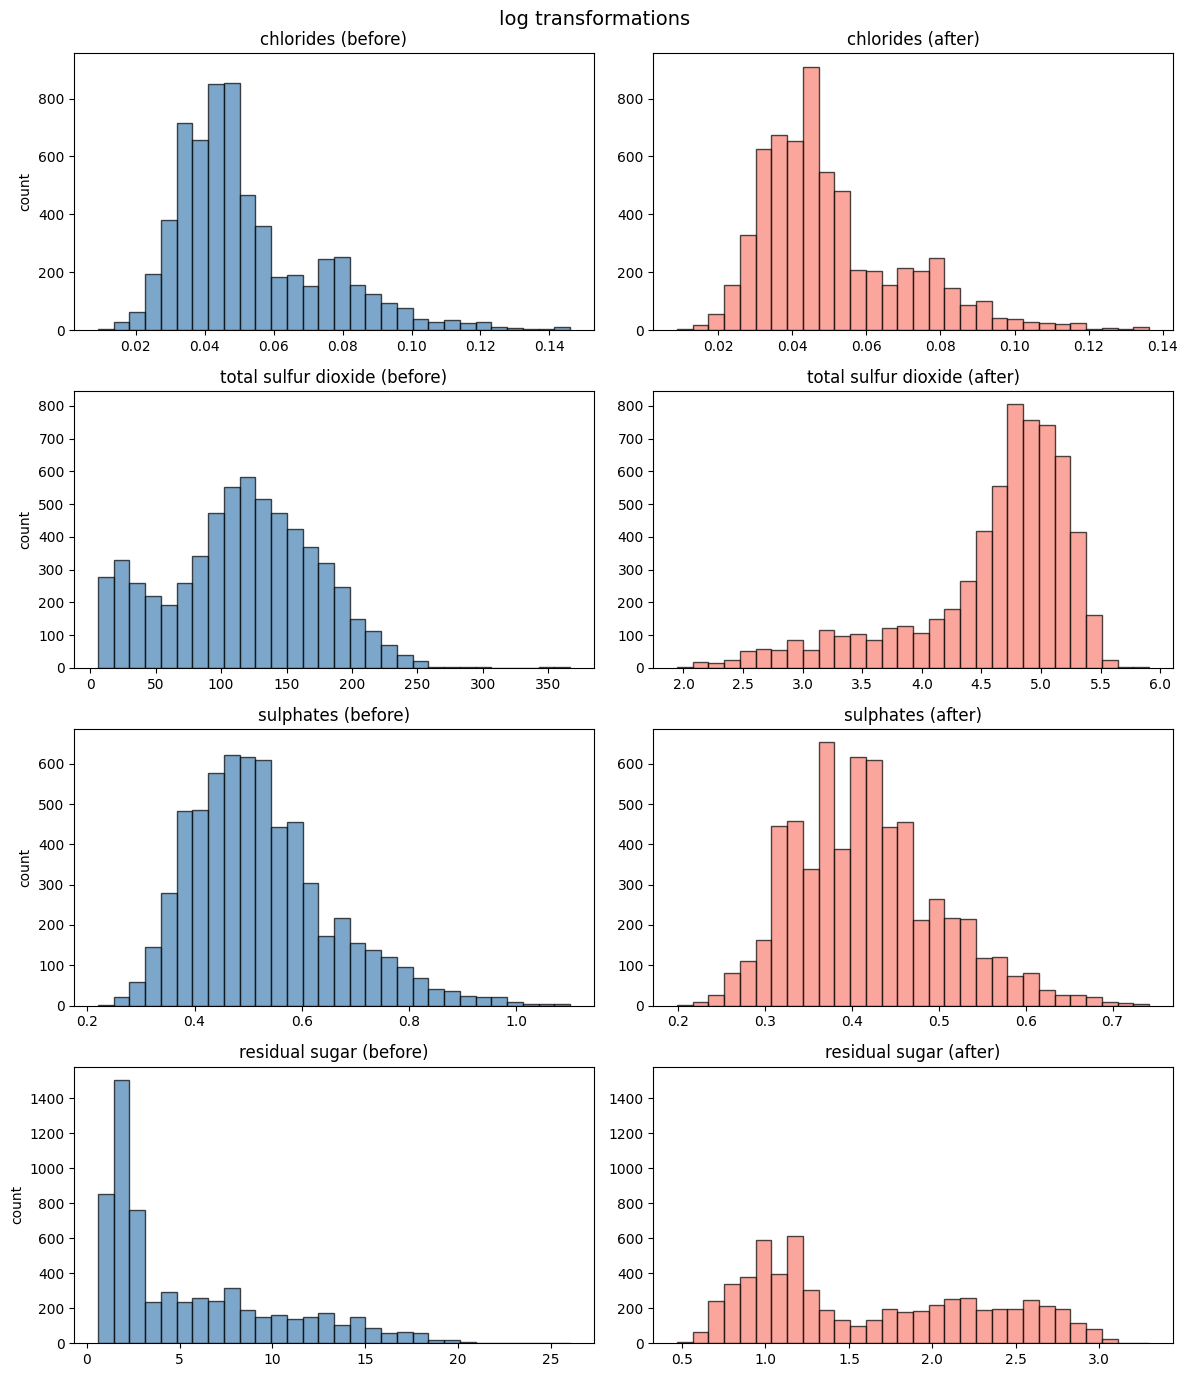

log transforms kept: ['sulphates', 'residual sugar']
log transforms reverted: ['chlorides', 'total sulfur dioxide']


In [8]:
# chlorides x class, alcohol x density are closely inversely associated 
# total sulfur dioxide x class closely positively associated, free sulfur x total sulfur doixide

# volatile acidity cannot be negative.

# preprocessing data what i feel is right such as imputation, feature transformations, (log or polynoimial transforms_, removing redundant features or outliers from the data.)

# remove volatile acidity. it contains negative values, is noisy, has near-zero correlation with every other feature
# class is noisy as well but informative - strong correlations with chlorides and total sulfur dioxide
clean_data = clean_data.drop(columns=["volatile acidity"])
#drop free sulur dioxide since very similar correlations as total sulfur dioxide, high correlation between them, and total sulfur dioxide has stronger correlation with class + domain knowledge says total sort of measures free anyways
clean_data = clean_data.drop(columns=["free sulfur dioxide"])

# log transformations on right skewed data
log_cols = ["chlorides", "total sulfur dioxide", "sulphates", "residual sugar"]
keep_log_cols = ["sulphates", "residual sugar"]
# revert these two log transforms because I found log transform worsened the data
revert_cols = ["chlorides", "total sulfur dioxide"]

fig, axes = plt.subplots(len(log_cols), 2, figsize=(12, 14))
fig.suptitle("log transformations", fontsize=14)

for i, col in enumerate(log_cols):
    axes[i, 0].hist(clean_data[col], bins=30, color="steelblue", edgecolor="black", alpha=0.7)
    axes[i, 0].set_title(f"{col} (before)")
    axes[i, 0].set_ylabel("count")

    clean_data[col] = np.log1p(clean_data[col])

    axes[i, 1].hist(clean_data[col], bins=30, color="salmon", edgecolor="black", alpha=0.7)
    axes[i, 1].set_title(f"{col} (after)")

    max_count = max(axes[i, 0].get_ylim()[1], axes[i, 1].get_ylim()[1])
    axes[i, 0].set_ylim(0, max_count)
    axes[i, 1].set_ylim(0, max_count)

plt.tight_layout()
plt.show()

# revert columns where log transform did not improve distribution
for col in revert_cols:
    clean_data[col] = np.expm1(clean_data[col])

print(f"log transforms kept: {keep_log_cols}")
print(f"log transforms reverted: {revert_cols}")

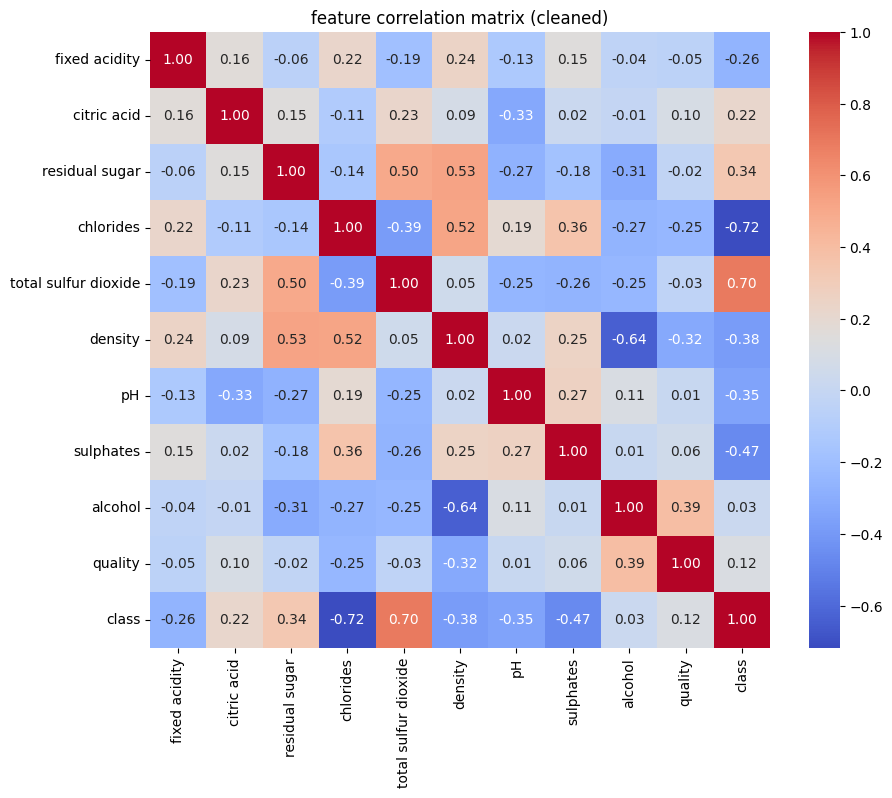

In [9]:
# final correlation matrix after all preprocessing
corr_matrix = clean_data.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("feature correlation matrix (cleaned)")
plt.show()

## Part 2 - Preparing the Data

When dividing your data into training, validation (assuming you do not use K-fold cross validation), and test sets it is import to ensure the same samples are used for training in all of your models. A good way to ensure that you have done this correctly is to check that your regression and classification training and testing data sets match after being prepared. You also should make sure that the shape of your training/testing sets make sense. For example, your training data array might have a shape of (num_samples_in_train, 11) since there are 11 features in the data set, and your regression and class label arrays would have a shape of (num_samples_in_train, ) representing that it is just a 1D array with a value for each training sample.

**Hint:** It is common to perform Min-Max scaling on the data so that your features take values between 0 and 1 (instead of using $x \in \mathcal{R}^d$ you may use $x \in [0,1]^d$).

In [10]:
# quality = regression target, class = classification target

# Normalize Data
scaler = MinMaxScaler()
normalized_data = scaler.fit_transform(clean_data)

# Shuffle the rows of the data
rng = np.random.default_rng(0)
shuffled_data = normalized_data[rng.permutation(len(normalized_data))]

# Split into features and labels
normalized_data = pd.DataFrame(normalized_data, columns=clean_data.columns)
X = normalized_data.drop(columns=["quality", "class"])
y_reg = normalized_data["quality"]
y_class = normalized_data["class"]

# Split into training and testing sets ensuring that the same samples are used for both regression and classification tasks
X_train, X_test, y_reg_train, y_reg_test, y_class_train, y_class_test = train_test_split(
    X, y_reg, y_class,
    test_size=0.2,
    random_state=42,
    stratify=y_class, #stratify class to prevent a class showing up in mostly one split
 )

# Check the shapes of the resulting datasets to ensure they are correct
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_reg_train:", y_reg_train.shape)
print("y_reg_test:", y_reg_test.shape)
print("y_class_train:", y_class_train.shape)
print("y_class_test:", y_class_test.shape)


X_train: (4987, 9)
X_test: (1247, 9)
y_reg_train: (4987,)
y_reg_test: (1247,)
y_class_train: (4987,)
y_class_test: (1247,)


The above assumes that students will use k-fold cross validation and thus a validation set is not explicitly needed.

## Part 3/4 - See PDF for details

Please put any methods you will use for your personal implementations here. Clearly label the code for each model you implement with a markdown sub-heading. "### Subheading"

A template of an sklearn model is provided for you. You will need to specify the model parameters, replace the fit method with the appropriate learning algorithm, and replace the predict function to output the prediction of your model on some input data.

I suggest you attempt the majority of the assignment first using the provided models from sklearn and then go back and try to replace them with your own implementations. 

### Self Implemented Model 1 (Logistic Regression)

In [11]:
# https://scikit-learn.org/stable/modules/generated/sklearn.base.BaseEstimator.html
class JoesLogisticRegression(BaseEstimator, ClassifierMixin):

    def __init__(self, learning_rate=0.01, n_iterations=1000, param=1):
        self .lr = learning_rate
        self.n_iterations = n_iterations
        self.param = param

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def fit(self, X, y):

        n_samples, n_features = X.shape
        self.weights_ = np.zeros(n_features)
        self.bias_ = 0
        self.classes_ = np.unique(y)

        for _ in range(self.n_iterations):
            linear_model = np.dot(X, self.weights_) + self.bias_
            y_predicted = self.sigmoid(linear_model)

            dw = (1 / n_samples) * np.dot(X.T, (y_predicted - y))
            db = (1 / n_samples) * np.sum(y_predicted - y)

            self.weights_ -= self.lr * dw
            self.bias_ -= self.lr * db

        self.is_fitted_ = True
        return self
    
    def predict(self, X):

        linear_model = np.dot(X, self.weights_) + self.bias_
        y_predicted = self.sigmoid(linear_model)
        return (y_predicted > 0.5).astype(int)
    
    def score(self, X, y):
        y_pred = self.predict(X)
        return np.mean(y_pred == y)

In [12]:
# Example usage of the MyEstimator class
estimator = JoesLogisticRegression(param=2)
estimator.learning_rate = estimator.lr
print(estimator.get_params())

X = np.array([[1, 2], [2, 3], [3, 4]])
y = np.array([1, 0, 1])

estimator.fit(X, y).predict(X)
estimator.set_params(param=3).fit(X, y)

print(estimator.predict(X))
print(estimator.score(X, y))

{'learning_rate': 0.01, 'n_iterations': 1000, 'param': 2}
[1 1 1]
0.6666666666666666


### Self Implemented Model 2

In [13]:
class JoesMLP(BaseEstimator, ClassifierMixin):

    def __init__(self, hidden_dims=(64, 32), learning_rate=0.01, n_iterations=1000):
        self.hidden_dims = hidden_dims
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations

    def _relu(self, Z):
        return np.maximum(0, Z)

    def _relu_deriv(self, Z):
        return (Z > 0).astype(float)

    def _sigmoid(self, Z):
        return 1 / (1 + np.exp(-Z))

    def _init_params(self, n_features):
        layer_dims = [n_features, *self.hidden_dims, 1]
        self.weights_ = []
        self.biases_ = []
        for i in range(len(layer_dims) - 1):
            W = np.random.randn(layer_dims[i], layer_dims[i+1]) * np.sqrt(2 / layer_dims[i])
            b = np.zeros((1, layer_dims[i+1]))
            self.weights_.append(W)
            self.biases_.append(b)

    def _forward(self, X):
        self.activations_ = [X]
        self.pre_activations_ = []

        A = X
        for i, (W, b) in enumerate(zip(self.weights_, self.biases_)):
            Z = A @ W + b
            self.pre_activations_.append(Z)
            if i < len(self.weights_) - 1:
                A = self._relu(Z)
            else:
                A = self._sigmoid(Z)
            self.activations_.append(A)

        return self.activations_[-1]

    def _backward(self, y):
        m = y.shape[0]
        # output layer error
        dZ = self.activations_[-1] - y.reshape(-1, 1)

        for i in reversed(range(len(self.weights_))):
            A_prev = self.activations_[i]
            dW = (A_prev.T @ dZ) / m
            db = dZ.mean(axis=0, keepdims=True)
            if i > 0:
                dZ = (dZ @ self.weights_[i].T) * self._relu_deriv(self.pre_activations_[i-1])
            self.weights_[i] -= self.learning_rate * dW
            self.biases_[i] -= self.learning_rate * db

    def fit(self, X, y):
        X = np.array(X)
        y = np.array(y)
        self.classes_ = np.unique(y)
        self._init_params(X.shape[1])

        for iteration in range(self.n_iterations):
            output = self._forward(X)
            self._backward(y)
            if (iteration + 1) % 100 == 0:
                loss = -np.mean(y * np.log(output.ravel() + 1e-8) + (1 - y) * np.log(1 - output.ravel() + 1e-8))

        self.is_fitted_ = True
        return self

    def predict(self, X):
        output = self._forward(np.array(X))
        return (output.ravel() > 0.5).astype(int)

    def score(self, X, y):
        return np.mean(self.predict(X) == np.array(y))

### K-Fold Cross-Validation

In [14]:
# This function assumes the data is already pre-proccessed via scaling and row-wise shuffled
# It returns the average score of the model on the training and validation sets as a dict
def k_fold_cross_validation(data, k, model):
    np.random.seed(42)
    n_samples = len(data)
    indices = np.arange(n_samples)
    fold_size = n_samples // k
    train_scores = []
    val_scores = []

    X = data[:, :-1]
    y = data[:, -1]

    for i in range(k):
        start_idx = i * fold_size
        end_idx = start_idx + fold_size if i < k - 1 else n_samples

        test_indices = indices[start_idx:end_idx]
        train_indices = np.concatenate([indices[:start_idx], indices[end_idx:]])

        X_train, X_val = X[train_indices], X[test_indices]
        y_train, y_val = y[train_indices], y[test_indices]

        model.fit(X_train, y_train)
        score_train = model.score(X_train, y_train)
        score_val = model.score(X_val, y_val)

        train_scores.append(score_train)
        val_scores.append(score_val)

    # Return the average training and validation scores across all folds
    return {
        "average_train_score": np.mean(train_scores),
        "average_val_score": np.mean(val_scores),
    }

In [15]:
# Part 5 sklearn models

from sklearn.linear_model import Ridge
from sklearn.cluster import KMeans

## Part 6 - Model Evaluation / Hyper-Parameter Tuning

For each model you will need to perform 2 experiments in which you vary a single hyper-parameter and keep all others fixed. 
For each experiment create a plot of the model's training and validation error. 
In total you will conduct 8 experiments. 

### Regression Model

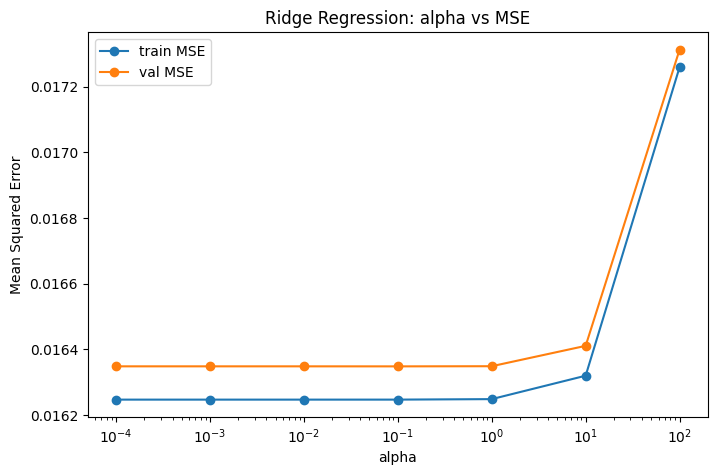

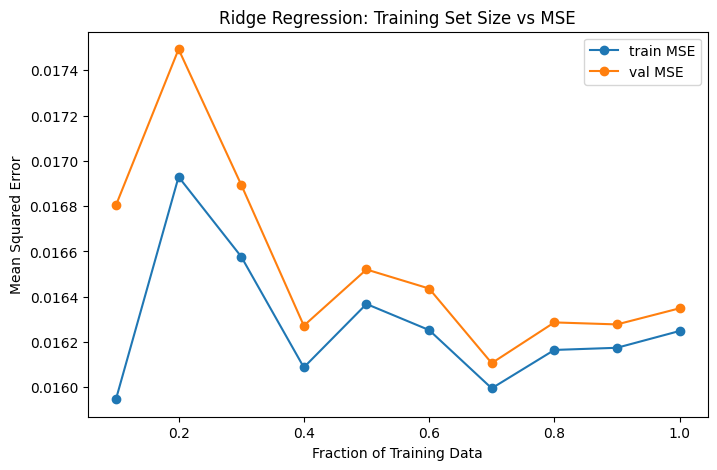

In [16]:
reg_data = np.column_stack([X_train.values, y_reg_train.values])

cv = KFold(n_splits=5, shuffle=True, random_state=42)

# Experiment 1: vary alpha
alphas = [0.0001, 0.001, 0.01, 0.1, 1, 10, 100]
train_errors, val_errors = [], []

for alpha in alphas:
    model = Ridge(alpha=alpha)
    results = cross_validate(model, X_train, y_reg_train, cv=cv,
                             scoring='neg_mean_squared_error',
                             return_train_score=True)
    train_errors.append(-results["train_score"].mean())
    val_errors.append(-results["test_score"].mean())

plt.figure(figsize=(8, 5)) 
plt.plot(alphas, train_errors, label="train MSE", marker='o')
plt.plot(alphas, val_errors, label="val MSE", marker='o')
plt.xscale("log")
plt.xlabel("alpha")
plt.ylabel("Mean Squared Error")
plt.title("Ridge Regression: alpha vs MSE")
plt.legend()
plt.show()

# Experiment 2: vary training set size
fractions = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
train_errors, val_errors = [], []

for frac in fractions:
    subset_size = int(len(X_train) * frac)
    X_subset = X_train[:subset_size]
    y_subset = y_reg_train[:subset_size]

    n_splits = min(5, subset_size // 2)
    cv_sub = KFold(n_splits=n_splits, shuffle=True, random_state=42)

    model = Ridge(alpha=1.0)  # use best alpha from exp 1 once you know it
    results = cross_validate(model, X_subset, y_subset, cv=cv_sub,
                             scoring='neg_mean_squared_error',
                             return_train_score=True)
    train_errors.append(-results["train_score"].mean())
    val_errors.append(-results["test_score"].mean())

plt.figure(figsize=(8, 5))
plt.plot(fractions, train_errors, label="train MSE", marker='o')
plt.plot(fractions, val_errors, label="val MSE", marker='o')
plt.xlabel("Fraction of Training Data")
plt.ylabel("Mean Squared Error")
plt.title("Ridge Regression: Training Set Size vs MSE")
plt.legend()
plt.show()

In [17]:
# it is apparent in the plots above that an alpha of [10^0, 10^1] causes a slight increase in err, and [10^1, 10^2] and after causes significant increase in err
# in the plot of changing training set size, at ~0.9 of training set size, val err reaches a lowest err. As it approaches 1, it goes back up likely due to 
# overfitting. Training err stays steady at and after ~0.9.
# therefore, best training fraction of data is at around 0.9. 

### Classification Model

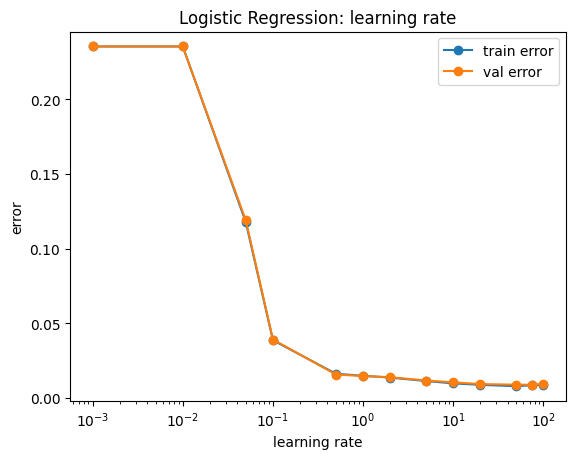

Best learning rate: 75.0 (val error: 0.0088)


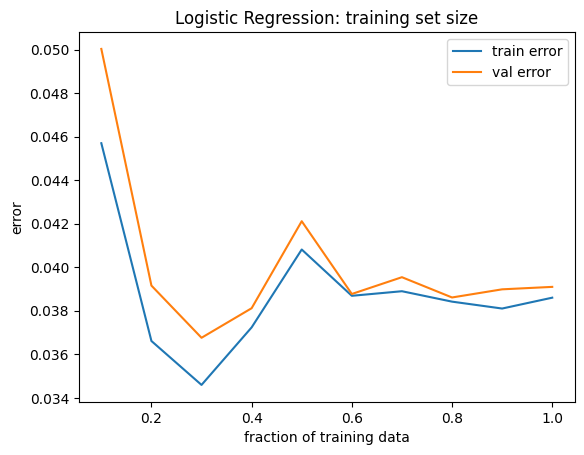

In [18]:
### Classification Model (Logistic Regression)

class_data = np.column_stack([X_train.values, y_class_train.values])

# Experiment 1: vary learning rate
learning_rates = [0.001, 0.01, 0.05, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0, 20.0, 50.0, 75.0, 100.0]
train_errors, val_errors = [], []

for lr in learning_rates:
    model = JoesLogisticRegression(learning_rate=lr, n_iterations=1000)
    results = k_fold_cross_validation(class_data, k=5, model=model)
    train_errors.append(1 - results["average_train_score"])
    val_errors.append(1 - results["average_val_score"])

plt.plot(learning_rates, train_errors, label="train error", marker='o')
plt.plot(learning_rates, val_errors, label="val error", marker='o')
plt.xscale("log")
plt.xlabel("learning rate")
plt.ylabel("error")
plt.title("Logistic Regression: learning rate")
plt.ylim(min(train_errors + val_errors) - 0.01, max(train_errors + val_errors) + 0.01)  # zoom
plt.legend()
plt.show()

best_lr = learning_rates[np.argmin(val_errors)]
print(f"Best learning rate: {best_lr} (val error: {min(val_errors):.4f})")

# Experiment 2: vary training set size
fractions = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
train_errors, val_errors = [], []

for frac in fractions:
    subset = class_data[:int(len(class_data) * frac)]
    model = JoesLogisticRegression(learning_rate=0.1, n_iterations=1000)
    results = k_fold_cross_validation(subset, k=5, model=model)
    train_errors.append(1 - results["average_train_score"])
    val_errors.append(1 - results["average_val_score"])

plt.plot(fractions, train_errors, label="train error")
plt.plot(fractions, val_errors, label="val error")
plt.xlabel("fraction of training data")
plt.ylabel("error")
plt.title("Logistic Regression: training set size")
plt.legend()
plt.show()

In [19]:
# in the learning rate plot, it is easy to see that higher the learning rate, the less the err. Therefore, maximizing the learning rate at 0.5 is best out
# of the range I tested.
# in the training set size plot, at around 0.8, val err reaches its low and afterwards it likely overfits because it goes slightly back up.

### Unsupervised Learning Model (K-Means Clustering)

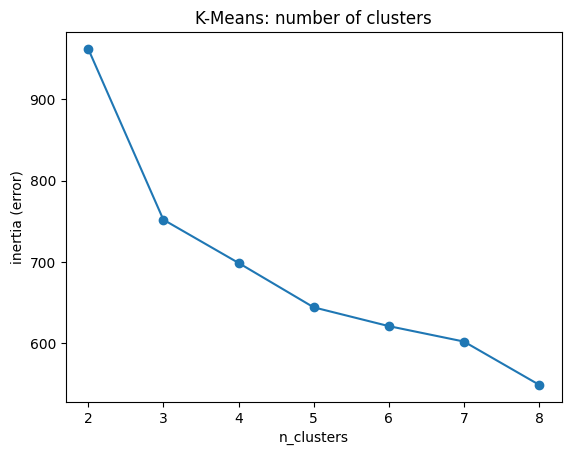

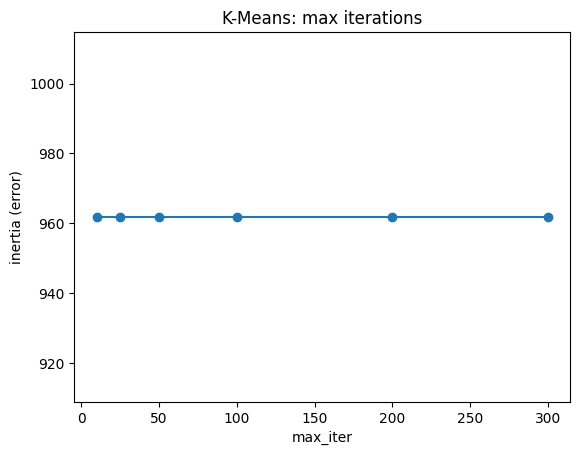

In [20]:
# K-Means has no labels so use inertia for error

X_train_np = X_train.values

# Experiment 1: vary n_clusters
k_values = [2, 3, 4, 5, 6, 7, 8]
inertias = []

for k in k_values:
    model = KMeans(n_clusters=k, random_state=42, n_init='auto')
    model.fit(X_train_np)
    inertias.append(model.inertia_)

plt.plot(k_values, inertias, marker='o')
plt.xlabel("n_clusters")
plt.ylabel("inertia (error)")
plt.title("K-Means: number of clusters")
plt.show()

# Experiment 2: vary max_iter
max_iters = [10, 25, 50, 100, 200, 300]
inertias = []

for max_iter in max_iters:
    model = KMeans(n_clusters=2, random_state=42, n_init='auto', max_iter=max_iter)
    model.fit(X_train_np)
    inertias.append(model.inertia_)

plt.plot(max_iters, inertias, marker='o')
plt.xlabel("max_iter")
plt.ylabel("inertia (error)")
plt.title("K-Means: max iterations")
plt.show()

In [21]:
# The elbow point where the rate of improvement flattens is 3.
# the plot is flat because KMeans converges before reaching the minimum max_iter tested. Convergence on this dataset occurs within approximately 10–15 iterations, so max_iter has no meaningful effect beyond that threshold. Use max_iter=300 (sklearn default) for simplicity and to ensure convergence is always reached.

### Additional Regression or Classification Model

In [22]:
# Experiment 1: vary learning rate
learning_rates = [0.001, 0.01, 0.05, 0.1, 0.5, 1.0, 2.0]
train_errors, val_errors = [], []

for lr in learning_rates:
    model = JoesMLP(learning_rate=lr, n_iterations=500)
    results = k_fold_cross_validation(class_data, k=5, model=model)
    train_errors.append(1 - results["average_train_score"])
    val_errors.append(1 - results["average_val_score"])

plt.plot(learning_rates, train_errors, label="train error")
plt.plot(learning_rates, val_errors, label="val error")
plt.xscale("log")
plt.xlabel("learning rate")
plt.ylabel("error")
plt.title("MLP: learning rate")
plt.legend()
plt.show()

best_mlp_lr = learning_rates[np.argmin(val_errors)]
print(f"Best MLP learning rate: {best_mlp_lr} (val error: {min(val_errors):.4f})")
for lr, tr, vl in zip(learning_rates, train_errors, val_errors):
    print(f"  lr={lr}: train={tr:.4f}, val={vl:.4f}")

# Experiment 2: vary hidden layer architecture
architectures = [(16,), (32,), (64,), (128,), (64,32), (64,32,16), (128,64,32), (256,128,64)]
arch_labels = ["(16,)", "(32,)", "(64,)", "(128,)", "(64,32)", "(64,32,16)", "(128,64,32)", "(256,128,64)"]
train_errors, val_errors = [], []

for arch in architectures:
    model = JoesMLP(hidden_dims=arch, learning_rate=0.01, n_iterations=1000)
    results = k_fold_cross_validation(class_data, k=5, model=model)
    train_errors.append(1 - results["average_train_score"])
    val_errors.append(1 - results["average_val_score"])

x = range(len(architectures))
plt.plot(x, train_errors, marker='o', label="train error")
plt.plot(x, val_errors, marker='o', label="val error")
plt.xticks(x, arch_labels, rotation=15)
plt.xlabel("hidden layer architecture")
plt.ylabel("error")
plt.title("MLP: hidden layer architecture")
plt.legend()
plt.show()

KeyboardInterrupt: 

In [ ]:
# The error rate for MLP increased until the learning rate peaked at 1, and then started to overfit at 2.
# as for the hidden layer architecture, having (256,128,64) is the best that I was able to run on my laptop due to machine limits. I assume the added complexity of hidden layers benefits the model until a certain point.

## Part 7 - Model Evaluation on the Test Set

In [ ]:
# TODO: use best hyperparameters found in p6 in this section.
X_test_np = X_test.values

### Regression Model

In [ ]:
ridge_final = Ridge(alpha=1.0)
ridge_final.fit(X_train.values, y_reg_train.values)
ridge_train_error = mean_squared_error(y_reg_train.values, ridge_final.predict(X_train.values))
ridge_test_error = mean_squared_error(y_reg_test.values, ridge_final.predict(X_test_np))
print(f"Ridge Regression - Train Error: {ridge_train_error:.4f}, Test Error: {ridge_test_error:.4f}")

Ridge Regression - Train Error: 0.0163, Test Error: 0.0159


### Classification Model

In [ ]:
logreg_final = JoesLogisticRegression(learning_rate=0.1, n_iterations=1000)
logreg_final.fit(X_train.values, y_class_train.values)
logreg_train_error = 1 - logreg_final.score(X_train.values, y_class_train.values)
logreg_test_error = 1 - logreg_final.score(X_test_np, y_class_test.values)
print(f"Logistic Regression - Train Error: {logreg_train_error:.4f}, Test Error: {logreg_test_error:.4f}")

Logistic Regression - Train Error: 0.0385, Test Error: 0.0401


### Unsupervised Learning Model (K-Means Clustering)

In [ ]:
kmeans_final = KMeans(n_clusters=2, random_state=42, n_init='auto')
kmeans_final.fit(X_train.values)
print(f"K-Means - Train Inertia: {kmeans_final.inertia_:.4f}")

K-Means - Train Inertia: 961.8832


### Additional Regression or Classification Model

In [ ]:
mlp_final = JoesMLP(hidden_dims=(64, 32), learning_rate=0.01, n_iterations=500)
mlp_final.fit(X_train.values, y_class_train.values)
mlp_train_error = 1 - mlp_final.score(X_train.values, y_class_train.values)
mlp_test_error = 1 - mlp_final.score(X_test_np, y_class_test.values)
print(f"MLP - Train Error: {mlp_train_error:.4f}, Test Error: {mlp_test_error:.4f}")

MLP - Train Error: 0.0993, Test Error: 0.1139


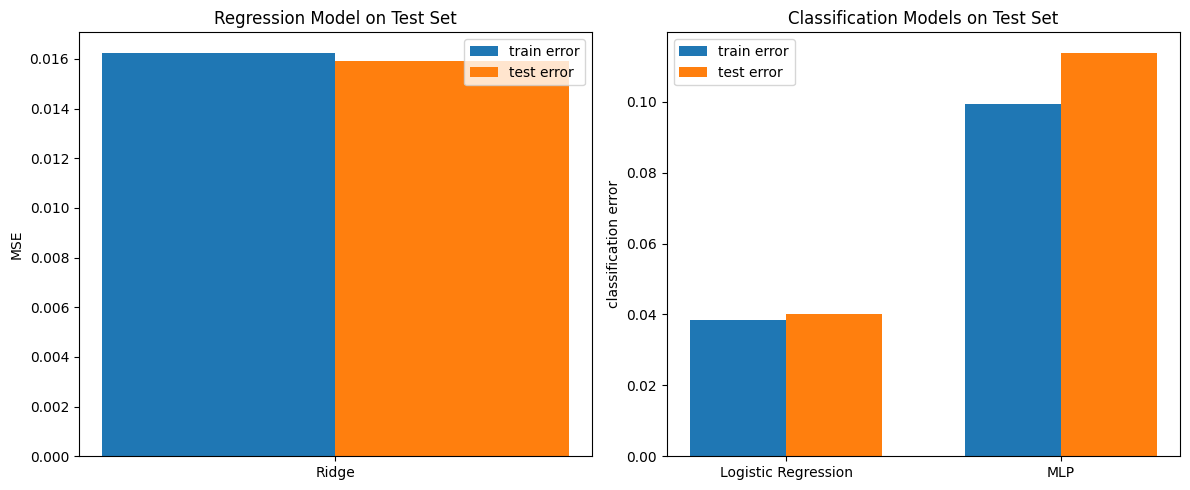

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Regression
x = np.arange(1)
width = 0.35
axes[0].bar(x - width/2, [ridge_train_error], width, label="train error")
axes[0].bar(x + width/2, [ridge_test_error], width, label="test error")
axes[0].set_xticks(x)
axes[0].set_xticklabels(["Ridge"])
axes[0].set_ylabel("MSE")
axes[0].set_title("Regression Model on Test Set")
axes[0].legend()

# Classification
class_models = ["Logistic Regression", "MLP"]
class_train = [logreg_train_error, mlp_train_error]
class_test = [logreg_test_error, mlp_test_error]
x = np.arange(len(class_models))
width = 0.35
axes[1].bar(x - width/2, class_train, width, label="train error")
axes[1].bar(x + width/2, class_test, width, label="test error")
axes[1].set_xticks(x)
axes[1].set_xticklabels(class_models)
axes[1].set_ylabel("classification error")
axes[1].set_title("Classification Models on Test Set")
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
# TODO: Other parts like report, etc., personalize p7.